In [101]:
import numpy as np                           # arrays and linear algebra
import pandas as pd                          # tables
import matplotlib.pyplot as plt 

from sklearn import decomposition            # PCA
from sklearn.preprocessing import StandardScaler, scale   # scaling [WEATHER][PCA]
from sklearn.decomposition import PCA        # same class as decomposition.PCA

np.set_printoptions(suppress=True)


In [102]:
cohort = pd.read_csv("../data/clean/cohort_cleaned.csv")

cohort_numeric = cohort.iloc[:, 3:]
cohort_numeric.head()

,durationInMs,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,overallSleepScore,lastNightAvg,lastNight5MinHigh,restingHeartRateInBeatsPerMinute,minHeartRateInBeatsPerMinute,maxHeartRateInBeatsPerMinute,averageStressInStressLevel,maxStressInStressLevel,steps,activeKilocalories,bmrKilocalories,moderateIntensityDurationInMs,vigorousIntensityDurationInMs
0,29340000,3540000.0,19800000.0,6000000.0,60000.0,78.0,63.0,112.0,51.0,48.0,107.0,43.0,99.0,2825,126,2333,0,0
1,23340000,3660000.0,17100000.0,2580000.0,300000.0,73.0,50.0,78.0,50.0,46.0,120.0,41.0,99.0,8040,628,2339,1440000,120000
2,20940000,4200000.0,13140000.0,3600000.0,60000.0,76.0,58.0,78.0,48.0,45.0,103.0,40.0,98.0,3394,160,2333,0,0
3,21240000,3660000.0,14880000.0,2700000.0,1680000.0,60.0,43.0,57.0,53.0,45.0,109.0,53.0,98.0,5823,275,2333,0,0
4,24000000,2700000.0,17160000.0,2580000.0,180000.0,75.0,60.0,97.0,50.0,48.0,106.0,37.0,95.0,5947,250,2333,0,0


In [103]:
cohort_scaled = StandardScaler().fit_transform(cohort_numeric)
cohort_scaled = pd.DataFrame(cohort_scaled, columns=cohort_numeric.columns)
cohort_scaled.head()

,durationInMs,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,overallSleepScore,lastNightAvg,lastNight5MinHigh,restingHeartRateInBeatsPerMinute,minHeartRateInBeatsPerMinute,maxHeartRateInBeatsPerMinute,averageStressInStressLevel,maxStressInStressLevel,steps,activeKilocalories,bmrKilocalories,moderateIntensityDurationInMs,vigorousIntensityDurationInMs
0,0.663921,-0.437534,0.593595,0.768266,-0.820246,0.718823,2.124708,2.481059,-0.937434,-0.795194,-0.626074,0.579124,0.763042,-1.001291,-0.820761,0.786862,-0.416734,-0.429300
1,-0.437900,-0.368617,-0.016940,-0.678965,-0.672007,0.392212,1.091931,0.842083,-1.059953,-1.057207,0.170181,0.372851,0.763042,0.286690,0.049856,0.806398,0.025920,-0.299812
2,-0.878629,-0.058491,-0.912392,-0.247335,-0.820246,0.588179,1.727486,0.842083,-1.304991,-1.188213,-0.871076,0.269715,0.613253,-0.860762,-0.761795,0.786862,-0.416734,-0.429300
3,-0.823538,-0.368617,-0.518936,-0.628185,0.180368,-0.456977,0.535820,-0.170225,-0.692396,-1.188213,-0.503573,1.610488,0.613253,-0.260856,-0.562351,0.786862,-0.416734,-0.429300
4,-0.316700,-0.919952,-0.003372,-0.678965,-0.746126,0.522857,1.886374,1.757981,-1.059953,-0.795194,-0.687324,-0.039694,0.163887,-0.230231,-0.605708,0.786862,-0.416734,-0.429300


In [104]:
pca = decomposition.PCA()
pca.fit(cohort_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [105]:
# Share of the total variance carried by each PC
explained_variance = pca.explained_variance_ratio_
print("explained variance ratio:", np.round(explained_variance, 4))

# Running total, and the first k that reaches a target
cumulative = np.cumsum(explained_variance)
print("cumulative              :", np.round(cumulative, 4))
k_95 = int(np.searchsorted(cumulative, 0.95)) + 1      # +1 because counting starts at 0  [SVD]
print("components needed for 95%:", k_95)

explained variance ratio: [0.2778 0.1386 0.1315 0.0867 0.0596 0.0553 0.0486 0.0431 0.0333 0.0311
 0.028  0.0204 0.013  0.011  0.0096 0.0068 0.0055 0.0002]
cumulative              : [0.2778 0.4164 0.5479 0.6346 0.6942 0.7494 0.798  0.8411 0.8744 0.9054
 0.9335 0.9539 0.9669 0.9779 0.9875 0.9944 0.9998 1.    ]
components needed for 95%: 12


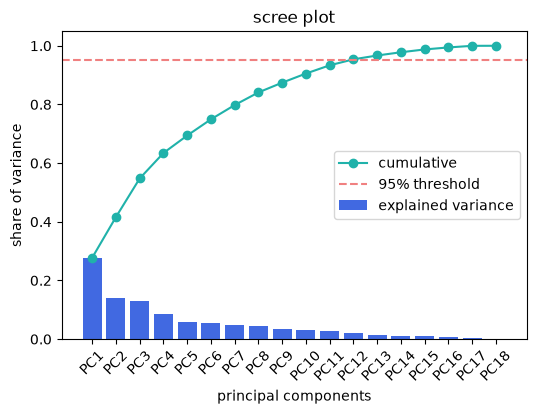

In [123]:
# Scree plot: bars = each PC's share, line = running total
pcs = ["PC1", "PC2", "PC3", "PC4","PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18"]
plt.figure(figsize=(6, 4))
plt.bar(pcs, explained_variance, color="RoyalBlue", label="explained variance")
plt.plot(pcs, cumulative, marker="o", color="LightSeaGreen", label="cumulative")
plt.xlabel("principal components")
plt.xticks(rotation=45)
plt.ylabel("share of variance")
plt.title("scree plot")
plt.axhline(y=0.95, color="LightCoral", linestyle="--", label="95% threshold")
plt.legend()
plt.savefig("../images/pca/scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [107]:
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=["PC1", "PC2", "PC3","PC4","PC5","PC6","PC7","PC8","PC9","PC10", "PC11","PC12","PC13","PC14","PC15","PC16","PC17","PC18"], index=cohort_scaled.columns)
print(df_loadings.round(2), "\n")

                                   PC1   PC2   PC3   PC4   PC5   PC6   PC7  \
durationInMs                     -0.13 -0.27  0.53 -0.08  0.11  0.20  0.08   
deepSleepDurationInMs            -0.07  0.09  0.07  0.52  0.13  0.29  0.54   
lightSleepDurationInMs           -0.03 -0.25  0.42 -0.39  0.14  0.19 -0.06   
remSleepInMs                     -0.19 -0.21  0.38  0.18 -0.11 -0.12 -0.10   
awakeDurationInMs                 0.05 -0.09 -0.10 -0.51 -0.14  0.42  0.47   
overallSleepScore                -0.30 -0.02  0.35  0.30 -0.03 -0.06 -0.07   
lastNightAvg                     -0.30  0.35  0.02 -0.17  0.02  0.04 -0.22   
lastNight5MinHigh                -0.28  0.34  0.04 -0.19  0.01  0.12 -0.17   
restingHeartRateInBeatsPerMinute  0.35 -0.28 -0.02  0.09  0.05 -0.06 -0.06   
minHeartRateInBeatsPerMinute      0.32 -0.32 -0.01  0.08  0.00 -0.09 -0.04   
maxHeartRateInBeatsPerMinute      0.26  0.26  0.26  0.03  0.05 -0.12  0.00   
averageStressInStressLevel        0.31  0.04  0.04 -0.07  0.42  

In [108]:
pc1_sorted = df_loadings.iloc[:,0].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC1 loadings sorted by magnitude:\n\n",pc1_sorted)

PC1 loadings sorted by magnitude:

 activeKilocalories                  0.350884
restingHeartRateInBeatsPerMinute    0.349039
minHeartRateInBeatsPerMinute        0.317516
averageStressInStressLevel          0.308538
lastNightAvg                       -0.297708
overallSleepScore                  -0.295240
lastNight5MinHigh                  -0.284496
maxHeartRateInBeatsPerMinute        0.263569
moderateIntensityDurationInMs       0.250799
vigorousIntensityDurationInMs       0.246168
remSleepInMs                       -0.185788
maxStressInStressLevel              0.168585
bmrKilocalories                     0.126720
durationInMs                       -0.125417
steps                               0.077033
deepSleepDurationInMs              -0.071108
awakeDurationInMs                   0.054073
lightSleepDurationInMs             -0.026421
Name: PC1, dtype: float64


In [109]:
pc2_sorted = df_loadings.iloc[:,1].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC2 loadings sorted by magnitude:\n\n",pc2_sorted)

PC2 loadings sorted by magnitude:

 steps                               0.367496
lastNightAvg                        0.351933
lastNight5MinHigh                   0.338347
minHeartRateInBeatsPerMinute       -0.316937
restingHeartRateInBeatsPerMinute   -0.280301
durationInMs                       -0.267098
maxHeartRateInBeatsPerMinute        0.258999
lightSleepDurationInMs             -0.252235
maxStressInStressLevel              0.244222
vigorousIntensityDurationInMs       0.239874
remSleepInMs                       -0.209055
activeKilocalories                  0.201932
moderateIntensityDurationInMs       0.154461
deepSleepDurationInMs               0.088069
awakeDurationInMs                  -0.085274
bmrKilocalories                     0.056462
averageStressInStressLevel          0.035870
overallSleepScore                  -0.022895
Name: PC2, dtype: float64


In [110]:
pc3_sorted = df_loadings.iloc[:,2].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC3 loadings sorted by magnitude:\n\n",pc3_sorted)

PC3 loadings sorted by magnitude:

 durationInMs                        0.526472
lightSleepDurationInMs              0.416577
remSleepInMs                        0.379570
overallSleepScore                   0.345281
maxHeartRateInBeatsPerMinute        0.261090
vigorousIntensityDurationInMs       0.256610
moderateIntensityDurationInMs       0.208984
activeKilocalories                  0.185089
maxStressInStressLevel              0.168212
steps                               0.136548
awakeDurationInMs                  -0.100882
bmrKilocalories                    -0.083287
deepSleepDurationInMs               0.074012
lastNight5MinHigh                   0.044922
averageStressInStressLevel          0.037893
restingHeartRateInBeatsPerMinute   -0.023956
lastNightAvg                        0.021533
minHeartRateInBeatsPerMinute       -0.005010
Name: PC3, dtype: float64


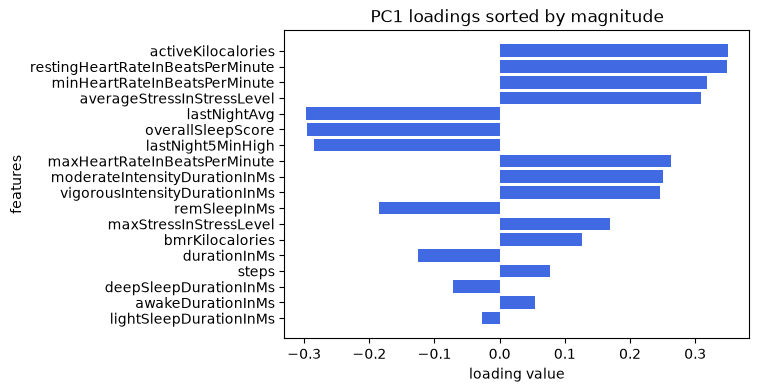

In [111]:
plt.figure(figsize=(6, 4))
plt.barh(pc1_sorted.index,pc1_sorted.values, color="RoyalBlue", label="PC1 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC1 loadings sorted by magnitude")
plt.savefig("../images/pca/pc1_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

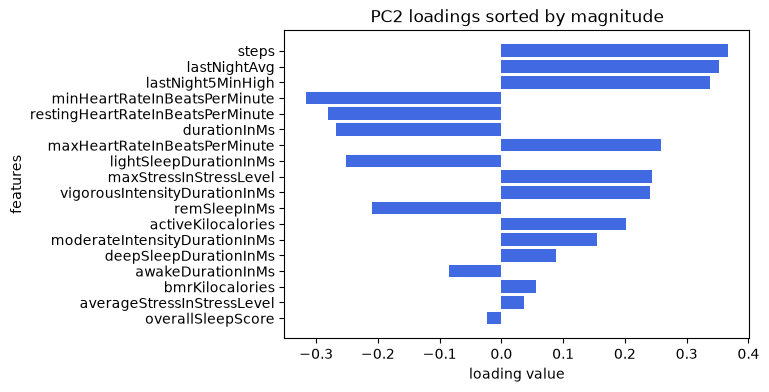

In [112]:
plt.figure(figsize=(6, 4))
plt.barh(pc2_sorted.index,pc2_sorted.values, color="RoyalBlue", label="PC2 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC2 loadings sorted by magnitude")
plt.savefig("../images/pca/pc2_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

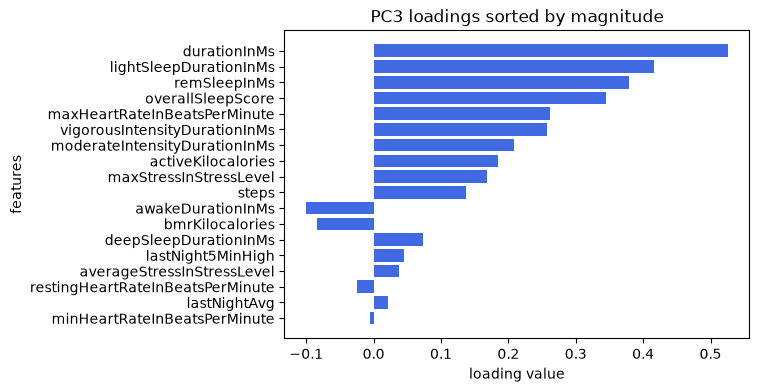

In [113]:
plt.figure(figsize=(6, 4))
plt.barh(pc3_sorted.index,pc3_sorted.values, color="RoyalBlue", label="PC3 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC3 loadings sorted by magnitude")
plt.savefig("../images/pca/pc3_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
Xd = cohort_scaled                            # (18731, 18), standardized to match the sklearn PCA
n = Xd.shape[0]                               # number of samples (nights)

Uf, Sf, Vtf = np.linalg.svd(Xd, full_matrices=False)       # 1. economy SVD (scaled data is already centered)
print("U:", Uf.shape, "  S:", Sf.shape, "  Vt:", Vtf.shape)

var_pc = Sf**2 / (n - 1)                      # 2. variance along each PC = eigenvalues

C = (Xd.T @ Xd) / (n - 1)                     # 3. the covariance matrix, 18 x 18
eig = np.sort(np.linalg.eigvalsh(C))[::-1]    # its eigenvalues, sorted biggest first

print("\n\nvariance from the SVD       :", np.round(var_pc, 4))
print("\n\neigenvalues of the covariance:", np.round(eig, 4))
print("\n\nidentical:", np.allclose(var_pc, eig))

pct = 100 * var_pc / var_pc.sum()             # 4. percent of variance (matches explained_variance_ratio_)
print("\n\npercent of variance:", np.round(pct, 2))

U: (18731, 18)   S: (18,)   Vt: (18, 18)


variance from the SVD       : [5.     2.4957 2.3672 1.5604 1.0722 0.9947 0.8753 0.7751 0.5988 0.5593
 0.5044 0.3675 0.2342 0.1989 0.173  0.1227 0.0986 0.0031]


eigenvalues of the covariance: [5.     2.4957 2.3672 1.5604 1.0722 0.9947 0.8753 0.7751 0.5988 0.5593
 0.5044 0.3675 0.2342 0.1989 0.173  0.1227 0.0986 0.0031]


identical: True


percent of variance: [27.78 13.86 13.15  8.67  5.96  5.53  4.86  4.31  3.33  3.11  2.8   2.04
  1.3   1.1   0.96  0.68  0.55  0.02]
